# CC5067NT Smart Data Discovery Coursework

## Network Traffic Data Analysis

# 1. Data understanding

In [4]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats

This section focuses on understanding the dataset by examining its structure, data types, and key variables. It helps to understand what the data contains before cleaning and analysis.

In [5]:
# Reads the contents of 'ids.csv' csv file and loads it into pandas DataFrame
df = pd.read_csv("ids.csv")

## 1.1 Dataset Structure and Data Types

In [7]:
# Shows the structure of the dataset, including column names, data types, non-null values, and total number of rows.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488115 entries, 0 to 488114
Data columns (total 80 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   488115 non-null  int64  
 1   Destination Port             488115 non-null  int64  
 2   Flow Duration                488115 non-null  int64  
 3   Total Fwd Packets            488115 non-null  int64  
 4   Total Backward Packets       488115 non-null  int64  
 5   Total Length of Fwd Packets  488115 non-null  int64  
 6   Total Length of Bwd Packets  488115 non-null  int64  
 7   Fwd Packet Length Max        488115 non-null  int64  
 8   Fwd Packet Length Min        488115 non-null  int64  
 9   Fwd Packet Length Mean       488115 non-null  float64
 10  Fwd Packet Length Std        488115 non-null  float64
 11  Bwd Packet Length Max        488115 non-null  int64  
 12  Bwd Packet Length Min        488115 non-null  int64  
 13 

## 1.2 Statistical Summary of All Numerical Columns

In [8]:
# Displays statistical summary of numerical columns, including count, mean, standard deviation, minimum, maximum, and quartile values.
df.describe()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,488115.00000,488115.000000,4.881150e+05,488115.000000,488115.000000,4.881150e+05,4.881150e+05,488115.000000,488115.000000,488115.000000,...,488115.000000,488115.000000,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05
mean,244057.00000,8216.354384,8.942263e+06,6.206931,6.185579,5.581399e+02,6.222017e+03,140.936187,17.142253,41.737297,...,3.436965,25.697270,6.169126e+04,4.144031e+04,1.325706e+05,3.851845e+04,2.606171e+06,1.184684e+05,2.695488e+06,2.483101e+06
std,140906.80766,17541.650108,2.748091e+07,69.852691,99.359121,2.738195e+04,1.788109e+05,438.404840,31.486744,119.415855,...,50.611058,5.851988,5.330001e+05,3.753807e+05,9.292890e+05,4.588439e+05,1.067120e+07,1.614595e+06,1.096955e+07,1.050593e+07
min,0.00000,0.000000,-2.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,122028.50000,53.000000,5.900000e+01,2.000000,1.000000,4.000000e+00,0.000000e+00,2.000000,0.000000,2.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,244057.00000,443.000000,3.100000e+02,2.000000,2.000000,4.900000e+01,7.200000e+01,32.000000,2.000000,29.000000,...,1.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,366085.50000,3221.000000,1.002090e+05,3.000000,2.000000,9.500000e+01,2.460000e+02,51.000000,35.000000,46.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,488114.00000,65533.000000,1.199999e+08,22673.000000,44553.000000,1.290000e+07,6.360000e+07,23360.000000,2065.000000,4317.097561,...,9130.000000,60.000000,6.520000e+07,3.810000e+07,7.910000e+07,6.520000e+07,1.200000e+08,7.530000e+07,1.200000e+08,1.200000e+08


## 2. Data Preparation

This section cleans and prepares the dataset so it can be used for analysis. It checks for missing values, duplicate records, incorrect data types, and unnecessary columns. It also helps to organize the data into a clear and usable format.

##  2.1 Write a python program to load data into pandas Data Frame and display last 50 records.

In [9]:
# Reads the contents of 'ids.csv' csv file and loads it into pandas DataFrame
df = pd.read_csv("ids.csv")

# Displays the last 50 records
df.tail(50)

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,488065,53,70591,2,2,66,194,33,33,33.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,488066,443,5572560,8,6,386,5205,205,0,48.250000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,488067,3013,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,488068,53,122130,2,2,80,272,40,40,40.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,488069,53,98106274,2,2,114,211,58,56,57.000000,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,488070,53,506,1,1,53,113,53,53,53.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,488071,53,3957631,2,2,120,260,79,41,60.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,488072,9102,2,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,488073,2135,111,2,2,4,12,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,488074,1048,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


## 2.2 Write a Python program to create a separate Data Frame containing only the following columns list for further analysis.

In [10]:
# Creates a separate DataFrame with only the required columns
columns = ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
           'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
           'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s',
           'Flow Packets/s', 'Packet Length Mean', 'Packet Length Std',
           'Average Packet Size', 'Active Mean', 'Idle Mean', 'Label']


# Creates a new DataFrame using only the selected columns from the original DataFrame
df_new = df[columns]


# Displays the first 5 records of the new DataFrame
df_new.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN


## 2.3 Write a Python program to check for NaN (missing values) and remove them from the newly created DataFrame.

In [11]:
# Check missing values before cleaning
print("==============================================")
print("Missing Values Before Cleaning")
print("==============================================")
print(df_new.isnull().sum())

# Count total missing values before cleaning
totalNaN = df_new.isna().sum()
print("----------------------------------------------")
print("Total missing values before cleaning:", totalNaN.sum())
print("----------------------------------------------")

# Remove rows that contain missing values and create a clean copy
df_cleaned = df_new.dropna().copy()

# Check missing values after cleaning
print("\n==============================================")
print("Missing Values After Cleaning")
print("==============================================")
print(df_cleaned.isnull().sum())

# Count total missing values after cleaning
totalNaNAfterCleaning = df_cleaned.isna().sum()
print("----------------------------------------------")
print("Total missing values after cleaning:", totalNaNAfterCleaning.sum())
print("----------------------------------------------")

Missing Values Before Cleaning
Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64
----------------------------------------------
Total missing values before cleaning: 36
----------------------------------------------

Missing Values After Cleaning
Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Mean         0
Bwd Packet Leng

## 2.4 Write a python program to check if duplicated records exist and find their total number.

In [12]:
# Check duplicated rows in the cleaned DataFrame
duplicateRows = df_cleaned.duplicated()

# Count total duplicated rows
duplicateCount = duplicateRows.sum()

print("==============================================")
print("Duplicate Record Checking")
print("==============================================")

# Display duplicate checking result
if duplicateCount == 0:
    print("Result: No duplicate records were found.")
else:
    print("Result: Duplicate records were found.")
    print("Total duplicate records:", duplicateCount)

Duplicate Record Checking
Result: Duplicate records were found.
Total duplicate records: 139389


## 2.5 Write a python program to show total number of columns. Also display name of all columns.

In [13]:
# Find total number of columns in the cleaned DataFrame
totalColumns = df_cleaned.shape[1]

print("==============================================")
print("Total Number of Columns")
print("==============================================")
print("Total columns:", totalColumns)

print("\n==============================================")
print("Column Names")
print("==============================================")

# Display all column names
print(df_cleaned.columns)

Total Number of Columns
Total columns: 16

Column Names
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
       'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
       'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
       'Active Mean', 'Idle Mean', 'Label'],
      dtype='object')


## 2.6 Rename the values in the Label column as follows: BENIGN – Normal Traffic Infiltration – Attack

In [14]:
# Displays original values in the Label column
print("==============================================")
print("Original Values in Label Column")
print("==============================================")
print(df_cleaned['Label'].value_counts())

# Replaces the Label column values with clearer names
df_cleaned['Label'] = df_cleaned['Label'].replace({
    'BENIGN': 'Normal Traffic',
    'Infiltration': 'Attack'
})

# Displays updated values in the Label column
print("\n==============================================")
print("Updated Values in Label Column")
print("==============================================")
print(df_cleaned['Label'].value_counts())

Original Values in Label Column
Label
BENIGN          288548
Infiltration    199531
Name: count, dtype: int64

Updated Values in Label Column
Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64


# 3. Data Analysis

This section analyses the dataset to identify patterns, relationships, and differences between Normal Traffic and Attack. Various statistical methods and visualizations are used to interpret the data and support decision-making.

## 3.1 Write a Python program to show summary statistics of sum, mean, standard deviation, skewness, and kurtosis of any 2 chosen numeric variable.

In [15]:
# Summary statistics of Flow Duration

print("======================================================")
print("Summary Statistics for Flow Duration")
print("======================================================")

print("Sum:", df_cleaned['Flow Duration'].sum())
print("Mean:", df_cleaned['Flow Duration'].mean())
print("Standard Deviation:", df_cleaned['Flow Duration'].std())
print("Skewness:", df_cleaned['Flow Duration'].skew())
print("Kurtosis:", df_cleaned['Flow Duration'].kurt())


# Summary statistics of Packet Length Mean

print("\n======================================================")
print("Summary Statistics for Packet Length Mean")
print("======================================================")

print("Sum:", df_cleaned['Packet Length Mean'].sum())
print("Mean:", df_cleaned['Packet Length Mean'].mean())
print("Standard Deviation:", df_cleaned['Packet Length Mean'].std())
print("Skewness:", df_cleaned['Packet Length Mean'].skew())
print("Kurtosis:", df_cleaned['Packet Length Mean'].kurt())

Summary Statistics for Flow Duration
Sum: 4364852868645
Mean: 8942922.905195676
Standard Deviation: 27481820.041128952
Skewness: 3.2508743768773116
Kurtosis: 9.246790962992351

Summary Statistics for Packet Length Mean
Sum: 41757628.631677166
Mean: 85.55506102839328
Standard Deviation: 173.87246683072507
Skewness: 4.935765643058977
Kurtosis: 34.61051191591095


## 3.2  Write a Python program to calculate and show correlation of all numeric variables. Display top 5 correlated feature

In [16]:
# Calculates correlation of all numeric variables
correlationMatrix = df_cleaned.corr(numeric_only=True)

# Converts correlation matrix into pairs and sort from highest to lowest
correlationPairs = correlationMatrix.abs().unstack().sort_values(ascending=False)

# Removes self-correlation values
correlationPairs = correlationPairs[correlationPairs != 1]

# Removes repeated correlation pairs
topCorrelationPairs = correlationPairs.drop_duplicates()

# Displays top 5 correlated feature pairs
print("======================================================================")
print("Top 5 Correlated Feature Pairs")
print("======================================================================")
print("Feature 1                    Feature 2                    Correlation")
print("======================================================================")
print(topCorrelationPairs.head())

Top 5 Correlated Feature Pairs
Feature 1                    Feature 2                    Correlation
Packet Length Mean           Average Packet Size            0.995068
Total Length of Bwd Packets  Total Backward Packets         0.961480
Total Fwd Packets            Total Backward Packets         0.949848
                             Total Length of Bwd Packets    0.920007
Packet Length Mean           Packet Length Std              0.887792
dtype: float64


# 4. Data Exploration

This section uses charts and statistical methods to explore the dataset. It helps to understand the distribution of the Label column and compare the differences between Normal Traffic and Attack records. Bar chart, pie chart, boxplot, and hypothesis testing are used in this section.

## 4.1 Plot a bar chart showing the frequency of each category in the Label column (with values as Normal Traffic and Attack). Determine whether the Label, as the dependent variable, is balanced or not in the dataset. Provide an analysis

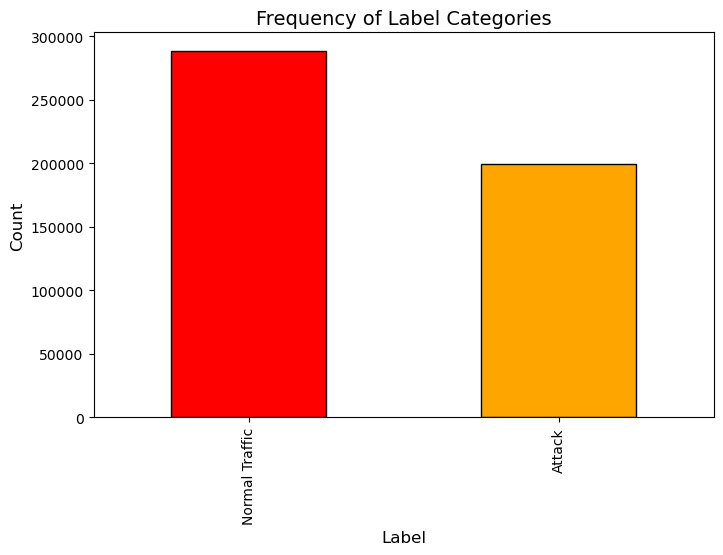

Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64

In [17]:
# Count each category in the Label column
label_counts = df_cleaned['Label'].value_counts()

# Plot bar chart for Label categories
label_counts.plot(kind='bar', color=['red', 'orange'], edgecolor='black', figsize=(8, 5))

# Add chart title and labels
plt.title("Frequency of Label Categories", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Display the chart
plt.show()

# Display frequency count
label_counts

## 4.2 Determine which category in the Label column (with values as Normal Traffic and Attack) has the highest average Flow Duration and the highest average Packet Length Mean. Visualize these findings with pie chart. 

A pie chart showing the average Flow Duration for each category in the Label column (Normal Traffic and Attack).

Average values by Label
                Flow Duration  Packet Length Mean
Label                                            
Attack             8909046.44               85.57
Normal Traffic     8966348.48               85.54


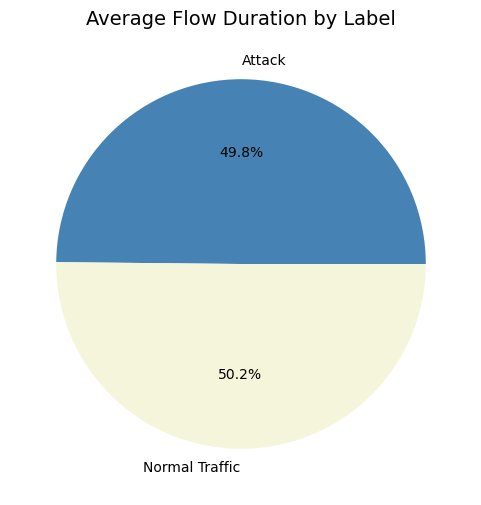

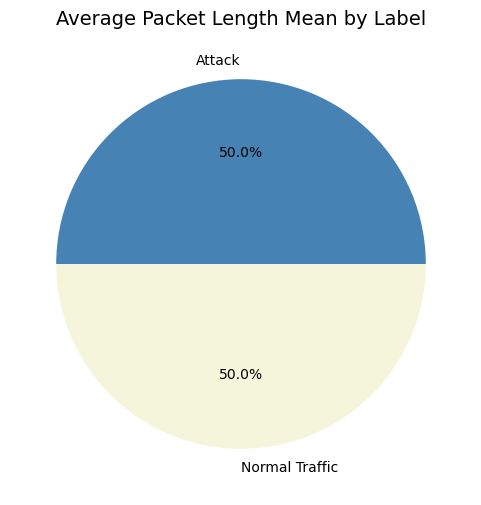

In [21]:
# Calculates average Flow Duration and Packet Length Mean for each Label category
avg_values = df_cleaned.groupby('Label')[['Flow Duration', 'Packet Length Mean']].mean()

# Rounds values to 2 decimal places for clear output
avg_values = avg_values.round(2)

# Displays average values
print("Average values by Label")
print("===============================================")
print(avg_values)

# Pie chart for Flow Duration
avg_values['Flow Duration'].plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['steelblue', 'beige'],
    figsize=(6, 6)
)

plt.title("Average Flow Duration by Label", fontsize=14)
plt.ylabel("")
plt.show()

# Pie chart for Packet Length Mean
avg_values['Packet Length Mean'].plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['steelblue', 'beige'],
    figsize=(6, 6)
)

plt.title("Average Packet Length Mean by Label", fontsize=14)
plt.ylabel("")
plt.show()

## 4.3 Generate boxplot of 'Fwd Packet Length Mean' grouped by the Label column to visualize the distribution for each attack type and normal traffic. Analyse the differences across these categories. 

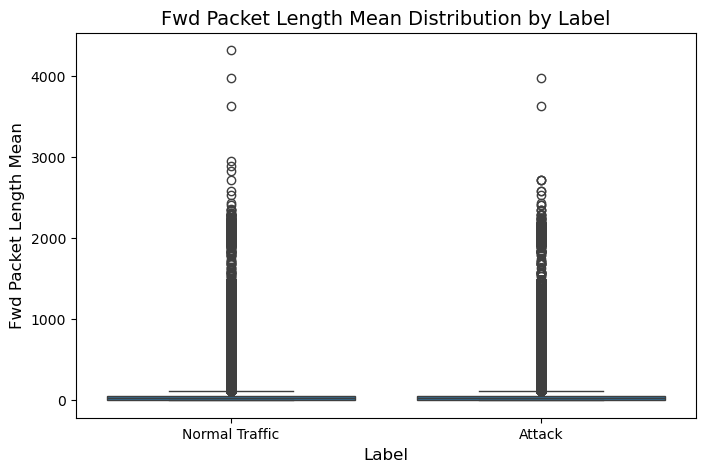

In [24]:
# Generates boxplot of Fwd Packet Length Mean grouped by Label
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_cleaned,
    x='Label',
    y='Fwd Packet Length Mean'
)

# Adds title and axis labels
plt.title("Fwd Packet Length Mean Distribution by Label", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Fwd Packet Length Mean", fontsize=12)

# Displays the boxplot
plt.show()

## 4.4 Perform a hypothesis test to determine if there is a significant difference in the mean Flow Duration between Normal Traffic and Attaclasses. State your null and alternative hypotheses, choose an appropriate test, perform it, and interpret the results.

In [25]:
# Defines the hypotheses for the test
# H0: There is no significant difference in mean Flow Duration between Normal Traffic and Attack.
# H1: There is a significant difference in mean Flow Duration between Normal Traffic and Attack.

# Selects Flow Duration values for both groups
normalTraffic = df_cleaned[df_cleaned['Label'] == 'Normal Traffic']['Flow Duration']
attackTraffic = df_cleaned[df_cleaned['Label'] == 'Attack']['Flow Duration']

# Performs independent t-test
tStatistic, pValue = stats.ttest_ind(normalTraffic, attackTraffic)

# Sets significance level
alpha = 0.05

# Displays test result
print("H0: Mean Flow Duration of Normal Traffic and Attack are equal.")
print("H1: Mean Flow Duration of Normal Traffic and Attack are different.")
print("===================================================================")

print("\nAlpha Value:", alpha)
print("T-statistic:", tStatistic)
print("P-value:", pValue)
print("====================================================================")

# Interprets the result
if pValue < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: There is a significant difference in mean Flow Duration between Normal Traffic and Attack.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Conclusion: There is no significant difference in mean Flow Duration between Normal Traffic and Attack.")

H0: Mean Flow Duration of Normal Traffic and Attack are equal.
H1: Mean Flow Duration of Normal Traffic and Attack are different.

Alpha Value: 0.05
T-statistic: 0.7161327588416807
P-value: 0.473909720385436

Decision: Fail to Reject H0
Conclusion: There is no significant difference in mean Flow Duration between Normal Traffic and Attack.
